In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 4nov4 f4ctori4l


--- Archivo 'df_2000_corrected.csv' cargado exitosamente ---

--- Resumen de Datos para Gap 2000 ---
  Tratamiento  Expectativa_Activa  Tasa_Mantiene       SEM  N_Sujetos  \
0  Bloque_CON                  -1       0.130435  0.071802         23   
1  Bloque_CON                   1       0.000000  0.000000          7   
2  Bloque_SIN                  -1       0.192308  0.078823         26   
3  Bloque_SIN                   1       0.400000  0.244949          5   
4        Dist                  -1       0.037037  0.037037         27   
5        Dist                   1       0.777778  0.146986          9   

  Expectativa_Label  
0    Expectativa -1  
1     Expectativa 1  
2    Expectativa -1  
3     Expectativa 1  
4    Expectativa -1  
5     Expectativa 1  


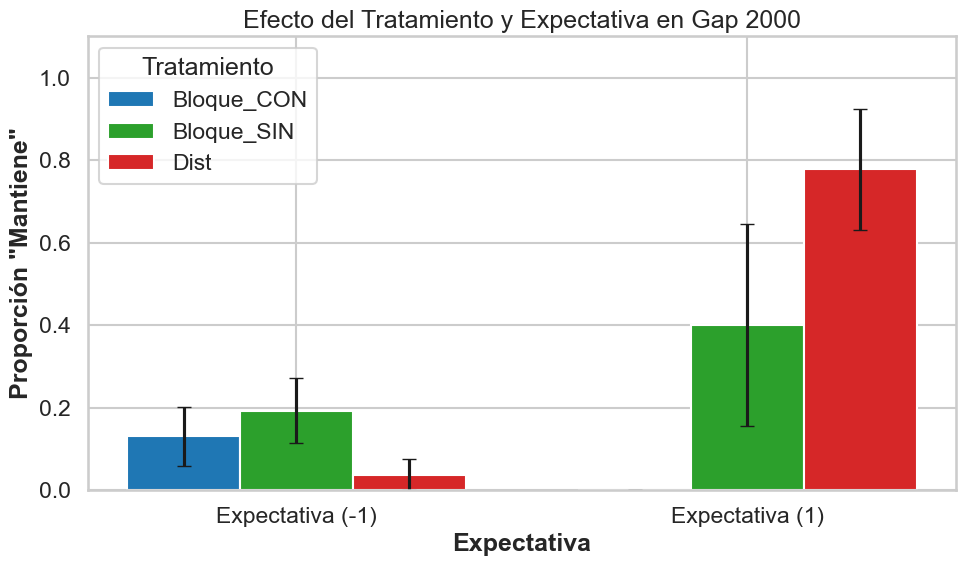


--- Resultados ANOVA Factorial (Gap 2000) ---
Modelo: Mantiene ~ Tratamiento * Expectativa
                                         sum_sq    df          F    PR(>F)
Intercept                              0.391304   1.0   3.435251  0.067059
C(Tratamiento)                         0.324090   2.0   1.422591  0.246399
C(Expectativa_Activa)                  0.091304   1.0   0.801559  0.372990
C(Tratamiento):C(Expectativa_Activa)   2.336505   2.0  10.256059  0.000096
Residual                              10.365676  91.0        NaN       NaN




In [20]:
# ==========================================
# 1. CONFIGURACIÓN (SOLO CAMBIA ESTO)
# ==========================================
# Escribe aquí el nombre de tu archivo CSV (ej: 'df_gap_0.csv', 'df_gap_1000.csv')
FILE_PATH = 'df_2000_corrected.csv' 

# Configuración Estética
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10, 6)
COLORES = {'Bloque_CON': '#1f77b4', 'Bloque_SIN': '#2ca02c', 'Dist': '#d62728'}

# ==========================================
# 2. CARGA Y DETECCIÓN AUTOMÁTICA
# ==========================================
try:
    df = pd.read_csv(FILE_PATH)
    print(f"--- Archivo '{FILE_PATH}' cargado exitosamente ---")
except FileNotFoundError:
    raise FileNotFoundError(f"Error: No se encontró el archivo '{FILE_PATH}'. Verifica la ruta.")

# Detectar automáticamente qué Gap estamos analizando (para el título)
try:
    gap_detectado = df['Gap_Size'].unique()
    if len(gap_detectado) == 1:
        gap_titulo = f"Gap {gap_detectado[0]}"
    else:
        gap_titulo = "Múltiples Gaps (Verificar Filtros)"
        print(f"Advertencia: El archivo contiene múltiples Gaps: {gap_detectado}")
except KeyError:
    gap_titulo = "Análisis de Gap" # Fallback si no existe la columna

# ==========================================
# 3. PROCESAMIENTO Y FILTROS
# ==========================================
# A. Filtros Estándar
# - Orden_1 == 1: Diseño Entre-Sujetos puro (primera exposición)
# - Expectativa: Solo -1 y 1
df_clean = df[
    (df['Orden_1'] == 1) & 
    (df['Expectativa_Activa'].isin([-1, 1]))
].copy()

# Renombrar Tratamiento si es necesario
if 'Dilema' in df_clean.columns:
    df_clean.rename(columns={'Dilema': 'Tratamiento'}, inplace=True)

# Verificar si hay datos suficientes
if df_clean.empty:
    raise ValueError("Error: El DataFrame quedó vacío después de filtrar. Verifica que 'Orden_1' tenga 1s y 'Expectativa_Activa' tenga -1/1.")

# B. Agregación por Sujeto (Crucial para evitar pseudoreplicación)
# Promediamos las respuestas de cada sujeto para tener 1 dato por persona
df_subject = df_clean.groupby(['ID_Sujeto', 'Tratamiento', 'Expectativa_Activa'])['Mantiene'].mean().reset_index()

# C. Tabla Resumen para Gráfico (Media y SEM grupal)
summary = df_subject.groupby(['Tratamiento', 'Expectativa_Activa'])['Mantiene'].agg(['mean', 'sem', 'count']).reset_index()
summary.rename(columns={'mean': 'Tasa_Mantiene', 'sem': 'SEM', 'count': 'N_Sujetos'}, inplace=True)
summary['Expectativa_Label'] = summary['Expectativa_Activa'].map({-1: 'Expectativa -1', 1: 'Expectativa 1'})

print(f"\n--- Resumen de Datos para {gap_titulo} ---")
print(summary)

# ==========================================
# 4. VISUALIZACIÓN
# ==========================================
plt.figure()

# Crear Barplot
# x = Grupos de Expectativa (-1 vs 1)
# hue = Barras de colores por Tratamiento
ax = sns.barplot(
    data=summary,
    x='Expectativa_Label',
    y='Tasa_Mantiene',
    hue='Tratamiento',
    palette=COLORES,
    edgecolor='black',
    alpha=0.9
)

# Añadir Barras de Error Manualmente
# (Iteramos sobre los tratamientos para asegurar que coincidan color y posición)
tratamientos_orden = ['Bloque_CON', 'Bloque_SIN', 'Dist'] # Orden por defecto de seaborn si no se especifica hue_order
# Para mayor seguridad, limpiamos y dibujamos con control total:
plt.clf()

bar_width = 0.25
grupos_x = np.arange(2) # Dos grupos: Exp -1 y Exp 1
desplazamientos = [0, bar_width, 2*bar_width] # Posiciones relativas de las 3 barras

for i, trat in enumerate(tratamientos_orden):
    # Filtrar datos de este tratamiento
    datos = summary[summary['Tratamiento'] == trat].sort_values('Expectativa_Activa')
    
    # Posición en X
    pos = [x + desplazamientos[i] for x in grupos_x]
    
    plt.bar(
        pos, 
        datos['Tasa_Mantiene'], 
        yerr=datos['SEM'], 
        width=bar_width, 
        color=COLORES.get(trat, 'grey'), 
        label=trat,
        capsize=5,
        edgecolor='white'
    )

# Formato del Gráfico
plt.xlabel('Expectativa', fontweight='bold')
plt.ylabel('Proporción "Mantiene"', fontweight='bold')
plt.title(f'Efecto del Tratamiento y Expectativa en {gap_titulo}')
plt.xticks([r + bar_width for r in range(len(grupos_x))], ['Expectativa (-1)', 'Expectativa (1)'])
plt.ylim(0, 1.1)
plt.legend(title='Tratamiento')
plt.tight_layout()
plt.show()

# ==========================================
# 5. ANÁLISIS ESTADÍSTICO (ANOVA FACTORIAL)
# ==========================================
print(f"\n--- Resultados ANOVA Factorial ({gap_titulo}) ---")
print("Modelo: Mantiene ~ Tratamiento * Expectativa")

formula = 'Mantiene ~ C(Tratamiento) * C(Expectativa_Activa)'
model = ols(formula, data=df_subject).fit()
anova_table = sm.stats.anova_lm(model, typ=3)

print(anova_table)
print("\n" + "="*50 + "\n")

--- Datos cargados correctamente ---
Tabla Resumen Generada:
Tratamiento  Gap_Size Expectativa_Label  Tasa_Mantiene      SEM  N_Sujetos
 Bloque_CON         0            Exp -1       0.357143 0.081682         14
 Bloque_CON         0             Exp 1       0.700000 0.133333         10
 Bloque_CON      1000            Exp -1       0.181818 0.084165         22
 Bloque_CON      1000             Exp 1       0.666667 0.166667          9
 Bloque_CON      1200            Exp -1       0.136364 0.074887         22
 Bloque_CON      1200             Exp 1       0.555556 0.175682          9
 Bloque_CON      2000            Exp -1       0.130435 0.071802         23
 Bloque_CON      2000             Exp 1       0.000000 0.000000          7
 Bloque_CON      2400            Exp -1       0.130435 0.071802         23
 Bloque_CON      2400             Exp 1       0.428571 0.202031          7
 Bloque_SIN         0            Exp -1       0.642857 0.142857          7
 Bloque_SIN         0             Exp 1

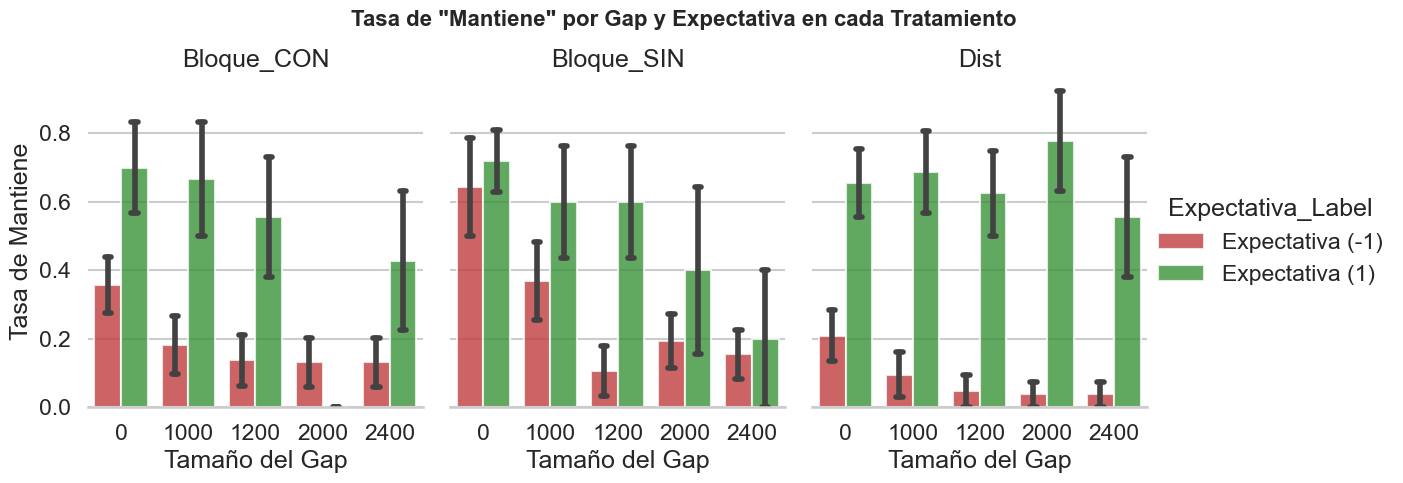

In [3]:


# ==========================================
# 1. CARGA Y CONFIGURACIÓN
# ==========================================
sns.set_theme(style="whitegrid", context="talk")
# Colores para las expectativas (Rojo para negativa, Azul/Verde para positiva)
COLORES_EXP = {-1: '#d62728', 1: '#2ca02c'} 

# Cargar df_long (contiene todos los gaps)
file_path = 'df_long.csv'
try:
    df = pd.read_csv(file_path)
    print("--- Datos cargados correctamente ---")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo {file_path}")

# ==========================================
# 2. PROCESAMIENTO
# ==========================================
# A. Filtros
# - Solo primer bloque (Orden_1 == 1) para mantener el diseño Entre-Sujetos
# - Solo expectativas claras (-1 y 1)
df_clean = df[
    (df['Orden_1'] == 1) & 
    (df['Expectativa_Activa'].isin([-1, 1]))
].copy()

# Renombrar Tratamiento
if 'Dilema' in df_clean.columns:
    df_clean.rename(columns={'Dilema': 'Tratamiento'}, inplace=True)

# B. Agregación por Sujeto (Crucial)
# Calculamos el promedio de cada sujeto para cada condición de Gap y Expectativa
# Esto asegura que las barras de error (SEM) sean correctas (basadas en N sujetos, no N ensayos)
df_subject_means = df_clean.groupby(['ID_Sujeto', 'Tratamiento', 'Gap_Size', 'Expectativa_Activa'])['Mantiene'].mean().reset_index()

# Crear etiqueta legible para la leyenda
df_subject_means['Expectativa_Label'] = df_subject_means['Expectativa_Activa'].map({-1: 'Expectativa (-1)', 1: 'Expectativa (1)'})

# ==========================================
# 3. VISUALIZACIÓN (3 PANELES)
# ==========================================
# Usamos catplot para crear una rejilla de gráficos (FacetGrid)
g = sns.catplot(
    data=df_subject_means,
    kind="bar",
    x="Gap_Size",
    y="Mantiene",
    col="Tratamiento",       # Esto crea los 3 paneles
    hue="Expectativa_Label", # Esto crea las barras agrupadas por expectativa
    palette={'Expectativa (-1)': '#d62728', 'Expectativa (1)': '#2ca02c'}, # Colores personalizados
    errorbar="se",           # Muestra el Error Estándar de la Media (SEM)
    capsize=0.1,             # Pequeños topes en las barras de error
    height=5,                # Altura de cada panel
    aspect=0.8,              # Ancho relativo de cada panel
           # Borde negro para las barras
    alpha=0.8
)

# Ajustes de Etiquetas y Títulos
g.set_axis_labels("Tamaño del Gap", "Tasa de Mantiene")
g.set_titles("{col_name}") # Título de cada panel = Nombre del Tratamiento
g.despine(left=True)

# Título General
plt.subplots_adjust(top=0.85) # Dar espacio arriba para el título
g.fig.suptitle('Tasa de "Mantiene" por Gap y Expectativa en cada Tratamiento', fontsize=16, fontweight='bold')

plt.show


#---------------------T4bl4-------------------------------------------------
#-----------------------------------------------------------------------

# Filters: Orden_1 == 1, Expectativa in [-1, 1]
df_clean = df[
    (df['Orden_1'] == 1) & 
    (df['Expectativa_Activa'].isin([-1, 1]))
].copy()

# Rename
if 'Dilema' in df_clean.columns:
    df_clean.rename(columns={'Dilema': 'Tratamiento'}, inplace=True)

# 1. Subject Means
df_subject_means = df_clean.groupby(['ID_Sujeto', 'Tratamiento', 'Gap_Size', 'Expectativa_Activa'])['Mantiene'].mean().reset_index()

# 2. Group Summary
summary_table = df_subject_means.groupby(['Tratamiento', 'Gap_Size', 'Expectativa_Activa'])['Mantiene'].agg(['mean', 'sem', 'count']).reset_index()

# Formatting
summary_table.rename(columns={'mean': 'Tasa_Mantiene', 'sem': 'SEM', 'count': 'N_Sujetos'}, inplace=True)
summary_table['Expectativa_Label'] = summary_table['Expectativa_Activa'].map({-1: 'Exp -1', 1: 'Exp 1'})

# Reorder columns
summary_table = summary_table[['Tratamiento', 'Gap_Size', 'Expectativa_Label', 'Tasa_Mantiene', 'SEM', 'N_Sujetos']]

print("Tabla Resumen Generada:")
print(summary_table.to_string(index=False))

# Optional: Save to CSV for user
#summary_table.to_csv('tabla_resumen_paneles.csv', index=False)

In [5]:
df_diff.head()

Expectativa_Activa,ID_Sujeto,Tratamiento,Gap_Size,-1,1,Diff_Expectativa
0,Suj_001,Bloque_CON,1000,1.0,NaN,NaN
1,Suj_001,Bloque_CON,1200,0.0,NaN,NaN
2,Suj_001,Bloque_CON,2000,0.0,NaN,NaN
3,Suj_001,Bloque_CON,2400,0.0,NaN,NaN
4,Suj_003,Bloque_CON,0,1.0,NaN,NaN


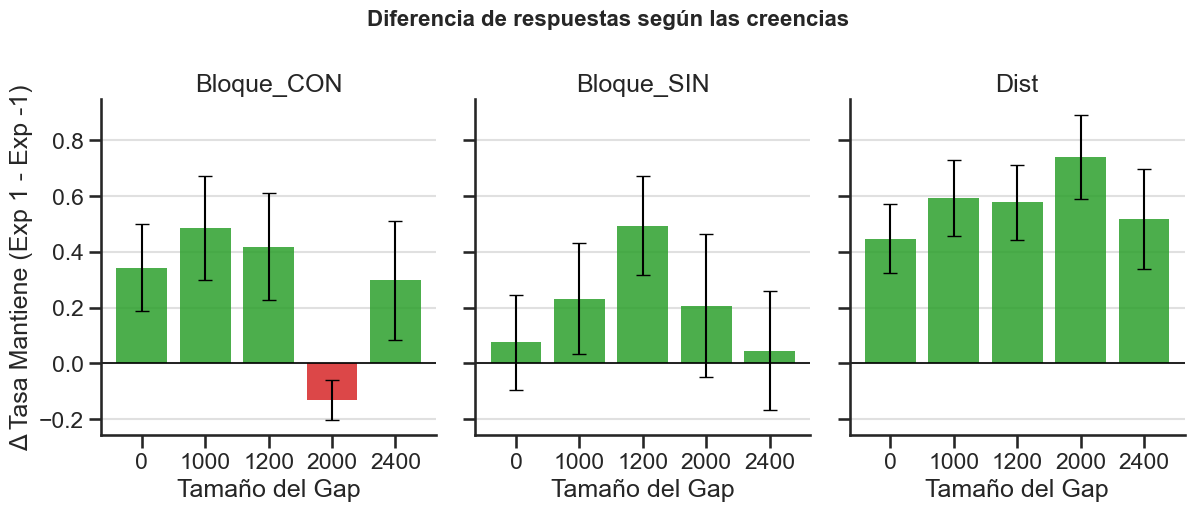

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# CÁLCULO DE DIFERENCIA Y SEM POR GRUPO
# ==========================================

# 1. Calculamos la media Y el SEM global para cada combinación
df_grouped = df_subject_means.groupby(['Tratamiento', 'Gap_Size', 'Expectativa_Activa'])['Mantiene'].agg(['mean', 'sem']).reset_index()

# 2. Pivotamos para separar las medias y los SEMs en columnas distintas
df_pivot = df_grouped.pivot(
    index=['Tratamiento', 'Gap_Size'], 
    columns='Expectativa_Activa', 
    values=['mean', 'sem']
)

# Aplanamos los nombres de las columnas (esto convertirá ('mean', 1) en 'mean_1')
df_pivot.columns = [f"{col[0]}_{col[1]}" for col in df_pivot.columns]
df_pivot = df_pivot.reset_index()

# 3. Calculamos la Diferencia y el SEM Combinado (Propagación del error)
df_pivot['Diff_Expectativa'] = df_pivot['mean_1'] - df_pivot['mean_-1']
# El SEM de una diferencia = raíz cuadrada de (SEM1^2 + SEM2^2)
df_pivot['SEM_Diff'] = np.sqrt(df_pivot['sem_1']**2 + df_pivot['sem_-1']**2)


# ==========================================
# VISUALIZACIÓN REFORMULADA
# ==========================================
# 1. Cambiamos 'whitegrid' por 'ticks' para limpiar el fondo inicial
sns.set_theme(style="ticks", context="talk")

def plot_custom_bars(data, **kwargs):
    ax = plt.gca()
    data = data.sort_values('Gap_Size')
    
    x_labels = data['Gap_Size'].astype(str).tolist()
    x_pos = np.arange(len(x_labels))
    y_vals = data['Diff_Expectativa']
    y_err = data['SEM_Diff']
    
    colores = ['#2ca02c' if val >= 0 else '#d62728' for val in y_vals]
    
    # 2. Forzamos a que las rayas queden detrás de las barras
    ax.set_axisbelow(True)
    
    # 3. Activamos SOLO las rayas horizontales (rayado)
    ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.7)
    
    # Dibujamos las barras (sin borde)
    ax.bar(x_pos, y_vals, yerr=y_err, color=colores, 
           capsize=5, ecolor='black', error_kw={'elinewidth': 1.5}, 
           linewidth=0, alpha=0.85)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.axhline(0, color='black', linestyle='-', linewidth=1.2)
# Creamos la cuadrícula de paneles (FacetGrid)
g = sns.FacetGrid(df_pivot, col="Tratamiento", height=5, aspect=0.8)

# Aplicamos nuestra función a cada panel
g.map_dataframe(plot_custom_bars)

# Ajustes estéticos de títulos y etiquetas
g.set_axis_labels("Tamaño del Gap", "Δ Tasa Mantiene (Exp 1 - Exp -1)")
g.set_titles("{col_name}")

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Diferencia de respuestas según las creencias ', fontsize=16, fontweight='bold')

plt.show()

In [10]:
# ==========================================
# TABLA RESUMEN DE COMPROBACIÓN (TAMAÑO DE MUESTRA Y MEDIAS)
# ==========================================

# 1. Agrupamos calculando media, error estándar (sem) y tamaño de muestra (count)
df_grouped_table = df_subject_means.groupby(['Tratamiento', 'Gap_Size', 'Expectativa_Activa'])['Mantiene'].agg(['mean', 'sem', 'count']).reset_index()

# 2. Pivotamos para tener Exp 1 y Exp -1 lado a lado en la tabla
df_table = df_grouped_table.pivot(
    index=['Tratamiento', 'Gap_Size'], 
    columns='Expectativa_Activa', 
    values=['mean', 'sem', 'count']
)

# 3. Aplanamos el nombre de las columnas generadas por el pivot
df_table.columns = [f"{col[0]}_{col[1]}" for col in df_table.columns]
df_table = df_table.reset_index()

# 4. Calculamos la diferencia para que coincida con el gráfico
df_table['Diferencia_Media'] = df_table['mean_1'] - df_table['mean_-1']

# 5. Renombramos las columnas para que la tabla sea legible
df_table = df_table.rename(columns={
    'count_1': 'N_Exp_1',
    'count_-1': 'N_Exp_-1',
    'mean_1': 'Media_Exp_1',
    'mean_-1': 'Media_Exp_-1'
})

# Convertimos los conteos a enteros (el pivot a veces los vuelve decimales)
df_table['N_Exp_1'] = df_table['N_Exp_1'].fillna(0).astype(int)
df_table['N_Exp_-1'] = df_table['N_Exp_-1'].fillna(0).astype(int)

# 6. Ordenamos las columnas para la impresión final
columnas_mostrar = [
    'Tratamiento', 'Gap_Size', 
    'N_Exp_1', 'N_Exp_-1', 
    'Media_Exp_1', 'Media_Exp_-1', 
    'Diferencia_Media'
]

print("\n" + "="*80)
print("TABLA RESUMEN: TAMAÑO DE MUESTRA Y DIFERENCIAS POR GAP")
print("="*80)
print(df_table[columnas_mostrar].round(3).to_string(index=False))


TABLA RESUMEN: TAMAÑO DE MUESTRA Y DIFERENCIAS POR GAP
Tratamiento  Gap_Size  N_Exp_1  N_Exp_-1  Media_Exp_1  Media_Exp_-1  Diferencia_Media
 Bloque_CON         0       10        14        0.700         0.357             0.343
 Bloque_CON      1000        9        22        0.667         0.182             0.485
 Bloque_CON      1200        9        22        0.556         0.136             0.419
 Bloque_CON      2000        7        23        0.000         0.130            -0.130
 Bloque_CON      2400        7        23        0.429         0.130             0.298
 Bloque_SIN         0       16         7        0.719         0.643             0.076
 Bloque_SIN      1000       10        19        0.600         0.368             0.232
 Bloque_SIN      1200       10        19        0.600         0.105             0.495
 Bloque_SIN      2000        5        26        0.400         0.192             0.208
 Bloque_SIN      2400        5        26        0.200         0.154             0.04